# Example Notebook — Enhancement + VAD 

## Feel free to create your own notebook, this is just for you to get it started


**Goal:** ASR performance on noisy recordings using:
- **1 noise reduction method** 
- **1 voice activity detection method** 

You will compare ASR performance across modes:
1. `raw` (as-recorded)
2. `enhanced`
3. `vad_trimmed`
4. `enhanced_plus_vad`

Use BOTH:
- synthetic noisy audio (from Notebook 01) AND/OR
- real-world audio (env1, env2)

> simply try: one enhancement + one VAD.


## 0) Install dependencies (run once)

```bash
pip install -U librosa soundfile numpy scipy pandas matplotlib jiwer webrtcvad noisereduce
```


In [1]:
import os, re
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from jiwer import cer
# from jiwer import compute_measures, cer
from scipy.signal import wiener
import webrtcvad

import noisereduce as nr
from glob import glob

plt.rcParams["figure.figsize"] = (10, 4)


c:\Users\K\Documents\usc\ee519\EE519-HW2\asr_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) Paths

We recommend starting with **real-world** data:
- `project/audio/real/env1/`
- `project/audio/real/env2/`

We will write enhanced files into:
- `project/enhancement/<mode>/<condition>/sXX.wav`


In [ ]:
PROJECT_ROOT = "./project"
SR = 16000

GT_PATH = os.path.join(PROJECT_ROOT, "sentences", "ground_truth.csv")
REAL_DIR = os.path.join(PROJECT_ROOT, "audio", "real")
SYN_DIR  = os.path.join(PROJECT_ROOT, "audio", "synthetic")

ENH_DIR  = os.path.join(PROJECT_ROOT, "enhancement")
OUT_DIR  = os.path.join(PROJECT_ROOT, "outputs", "metrics")
os.makedirs(ENH_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)


In [3]:
def read_audio_mono(path, sr=SR):
    """Load audio and return waveform (float32, mono) at sr."""
    wav, file_sr = sf.read(path)
    # if stereo, convert to mono
    if wav.ndim > 1:
        wav = np.mean(wav, axis=1)
    if file_sr != sr:
        wav = librosa.resample(wav.astype("float32"), orig_sr=file_sr, target_sr=sr)
    # ensure float32
    return wav.astype("float32")

def write_audio(path, audio, sr=SR):
    """Write float32 audio to path, normalized to -1..1 if needed."""
    # ensure dir exists
    os.makedirs(os.path.dirname(path), exist_ok=True)
    # scale to avoid clipping
    maxv = np.max(np.abs(audio)) if audio.size else 1.0
    if maxv > 1.0:
        audio = audio / maxv
    sf.write(path, audio, sr, subtype="PCM_16")

## 2) Enhancement method (choose ONE)

Pick at least 1 from any source:

In [12]:
def enhance_spectral_gating(input_wav, sr=SR, prop_decrease=1.0, n_fft=2048, hop_length=512):
    """
    Perform simple enhancement using noisereduce.reduce_noise.
    - input_wav: 1D numpy float audio at sr
    - prop_decrease: strength parameter (1.0 = full reduction)
    Returns enhanced audio (float32).
    """
    # Estimate a noise clip automatically from the first 0.5s (if possible)
    # If audio is short, it will still work with default behaviour
    # Tune parameters if you need stronger/weaker reduction
    try:
        # Using spectral gating: noise estimate left to the function
        enhanced = nr.reduce_noise(
            y=input_wav,
            sr=sr,
            prop_decrease=prop_decrease,
            n_fft=n_fft,
            hop_length=hop_length,
        )
        return enhanced.astype("float32")
    except Exception as e:
        print("Enhancement failed, returning original. Error:", e)
        return input_wav

## 3) Voice Activity Detection (VAD) 

Pick at least 1 from any source:

In [13]:
VAD_FRAME_MS = 30   # 10/20/30 ms frames acceptable for webrtcvad
VAD_AGGRESSIVENESS = 2  # 0..3 (higher = more aggressive)

def frame_generator(frame_ms, audio, sample_rate):
    n = int(sample_rate * (frame_ms / 1000.0))
    offset = 0
    while offset + n < len(audio):
        yield audio[offset:offset + n]
        offset += n

def vad_trim(y, sr=SR, frame_ms=VAD_FRAME_MS, aggressiveness=VAD_AGGRESSIVENESS):
    """
    Return trimmed audio where non-speech frames removed.
    Uses energy-quantized 16-bit PCM frames for webrtcvad.
    """
    vad = webrtcvad.Vad(int(aggressiveness))
    # webrtcvad expects 16-bit PCM bytes
    # convert float32 in [-1,1] to int16
    pcm16 = (y * 32767).astype(np.int16)
    bytes_per_frame = int(sr * (frame_ms/1000.0)) * 2  # 2 bytes per sample
    frames = list(frame_generator(frame_ms, pcm16, sr))
    voiced_frames = []
    for frame in frames:
        # bytes for this frame
        b = frame.tobytes()
        is_speech = False
        try:
            is_speech = vad.is_speech(b, sample_rate=sr)
        except Exception:
            # in case frame length mismatch, pad
            padlen = int(sr * (frame_ms/1000.0)) - len(frame)
            if padlen > 0:
                b = frame.tobytes() + (b'\x00' * padlen * 2)
                is_speech = vad.is_speech(b, sr)
        if is_speech:
            voiced_frames.append(frame)

    if len(voiced_frames) == 0:
        # no voiced frames detected; return original to avoid empty audio
        return y

    voiced = np.concatenate(voiced_frames).astype(np.int16)
    voiced = voiced.astype(np.float32) / 32767.0
    return voiced

In [14]:
def _frame_generator(frame_duration_ms, audio, sample_rate):
    """Yield successive frames from audio (PCM16 int16) for webrtcvad."""
    n_bytes_per_sample = 2  # 16 bit
    frame_length = int(sample_rate * (frame_duration_ms / 1000.0))
    offset = 0
    while offset + frame_length <= len(audio):
        yield audio[offset:offset + frame_length]
        offset += frame_length

def vad_trim_audio_float(y, sr=SR, vad_mode=2, frame_duration_ms=30, padding_ms=300):
    """
    Trim non-speech using webrtcvad.
    - y: float32 audio in -1..1
    - returns: trimmed float32 audio (concatenated voiced segments)
    Approach:
      - convert to 16-bit PCM
      - run VAD on frames
      - keep voiced frames with a small padding (padding_ms)
    """
    # convert to 16-bit PCM
    pcm16 = (y * 32767).astype(np.int16)
    sample_rate = sr
    vad = webrtcvad.Vad()
    vad.set_mode(vad_mode)  # 0-3 (3 = most aggressive)
    frame_ms = frame_duration_ms
    frame_len = int(sample_rate * frame_ms / 1000)

    if frame_len == 0:
        raise ValueError("frame_duration_ms too small for given sample rate")

    # pad to multiple of frame_len
    n_frames = int(np.ceil(len(pcm16) / frame_len))
    padded = np.zeros(n_frames * frame_len, dtype=np.int16)
    padded[:len(pcm16)] = pcm16

    voiced_mask = np.zeros(n_frames, dtype=bool)
    for i in range(n_frames):
        start = i * frame_len
        frame = padded[start:start + frame_len].tobytes()
        try:
            is_speech = vad.is_speech(frame, sample_rate)
        except Exception:
            # if frame bytes are invalid, treat as non-speech
            is_speech = False
        voiced_mask[i] = is_speech

    # apply padding (extend speech regions by padding_ms)
    pad_frames = int(np.ceil(padding_ms / frame_duration_ms))
    voiced_mask_padded = np.copy(voiced_mask)
    for i, v in enumerate(voiced_mask):
        if v:
            start = max(0, i - pad_frames)
            end = min(n_frames, i + pad_frames + 1)
            voiced_mask_padded[start:end] = True

    # collect voiced audio
    voiced_audio = []
    for i, keep in enumerate(voiced_mask_padded):
        if keep:
            start = i * frame_len
            voiced_audio.append(padded[start:start + frame_len])
    if not voiced_audio:
        # If nothing detected, return short silence
        return np.zeros(0, dtype="float32")
    voiced_concat = np.concatenate(voiced_audio).astype(np.int16)[:len(pcm16)]
    out = (voiced_concat.astype(np.float32) / 32767.0).astype("float32")
    return out

## 4) Build processed datasets

You can choose inputs from:
- `real` (env1/env2)  ✅ recommended
- `synthetic` noise folders

This will produce four modes:
- raw (reference paths)
- enhanced
- vad_trimmed
- enhanced_plus_vad


In [15]:
def process_single_file(input_path, out_base_dir, sr=SR,
                        do_enhance=True, do_vad=True,
                        enh_func=enhance_spectral_gating,
                        vad_func=vad_trim_audio_float,
                        enh_kwargs=None, vad_kwargs=None):
    """
    Process a single audio file and write four variants:
      - raw (copy of original, resampled/mono)
      - enhanced
      - vad_trimmed
      - enhanced_plus_vad
    Returns dict with paths for each mode.
    """
    enh_kwargs = enh_kwargs or {}
    vad_kwargs = vad_kwargs or {}

    # read
    y = read_audio_mono(input_path, sr=sr)

    # prepare path components
    fname = os.path.splitext(os.path.basename(input_path))[0] + ".wav"

    paths = {}

    # RAW: normalized/resampled copy
    raw_dir = os.path.join(out_base_dir, "raw")
    os.makedirs(raw_dir, exist_ok=True)
    raw_out = os.path.join(raw_dir, fname)
    write_audio(raw_out, y, sr=sr)
    paths["raw"] = raw_out

    # ENHANCED
    if do_enhance:
        y_enh = enh_func(y, sr=sr, **enh_kwargs)
    else:
        y_enh = y
    enh_dir = os.path.join(out_base_dir, "enhanced")
    os.makedirs(enh_dir, exist_ok=True)
    enh_out = os.path.join(enh_dir, fname)
    write_audio(enh_out, y_enh, sr=sr)
    paths["enhanced"] = enh_out

    # VAD_TRIMMED (applied to raw)
    if do_vad:
        y_vad = vad_func(y, sr=sr, **vad_kwargs)
    else:
        y_vad = y
    vad_dir = os.path.join(out_base_dir, "vad_trimmed")
    os.makedirs(vad_dir, exist_ok=True)
    vad_out = os.path.join(vad_dir, fname)
    write_audio(vad_out, y_vad, sr=sr)
    paths["vad_trimmed"] = vad_out

    # ENHANCED + VAD
    if do_vad:
        y_enh_vad = vad_func(y_enh, sr=sr, **vad_kwargs)
    else:
        y_enh_vad = y_enh
    enh_vad_dir = os.path.join(out_base_dir, "enhanced_plus_vad")
    os.makedirs(enh_vad_dir, exist_ok=True)
    enh_vad_out = os.path.join(enh_vad_dir, fname)
    write_audio(enh_vad_out, y_enh_vad, sr=sr)
    paths["enhanced_plus_vad"] = enh_vad_out

    return paths

def build_processed_dataset(input_root_dirs,
                            out_enh_root=ENH_DIR,
                            condition_name=None,
                            sr=SR,
                            patterns=("*.wav",),
                            do_enhance=True, do_vad=True,
                            enh_func=enhance_spectral_gating,
                            vad_func=vad_trim_audio_float,
                            enh_kwargs=None, vad_kwargs=None):
    """
    Walk each input_root_dirs (list of directories), process each wav found,
    and write four-mode outputs under:
      out_enh_root/<mode>/<condition_name>/filename.wav

    Returns a pandas DataFrame manifest with columns:
      original_path, mode, condition, out_path
    """
    enh_kwargs = enh_kwargs or {}
    vad_kwargs = vad_kwargs or {}

    rows = []
    if isinstance(input_root_dirs, str):
        input_root_dirs = [input_root_dirs]

    for input_root in input_root_dirs:
        # condition_name helps label outputs (e.g., 'env1', 'env2', 'synthetic_noiseX')
        cond = condition_name or os.path.basename(os.path.normpath(input_root))
        # find wavs
        files = []
        for pat in patterns:
            files.extend(glob(os.path.join(input_root, "**", pat), recursive=True))
        files = sorted(files)

        if not files:
            print(f"Warning: no files found under {input_root}")
            continue

        for f in files:
            # create per-condition target base dir
            out_base = os.path.join(out_enh_root, "{mode}", cond)  # we'll format for each mode later
            # actually process and write to a temporary per-input dir, then move files to mode dirs
            # We'll call process_single_file with a unique per-file temp base inside out_enh_root/tmp/<cond>/<fname>
            temp_base = os.path.join(out_enh_root, "tmp", cond)
            os.makedirs(temp_base, exist_ok=True)
            processed = process_single_file(f, temp_base,
                                            sr=sr,
                                            do_enhance=do_enhance,
                                            do_vad=do_vad,
                                            enh_func=enh_func,
                                            vad_func=vad_func,
                                            enh_kwargs=enh_kwargs,
                                            vad_kwargs=vad_kwargs)
            # move files to correct mode/condition layout
            for mode, p in processed.items():
                dest_dir = os.path.join(out_enh_root, mode, cond)
                os.makedirs(dest_dir, exist_ok=True)
                dest_path = os.path.join(dest_dir, os.path.basename(p))
                # move (or overwrite) file
                # simple copy via read/write to avoid cross-filesystem issues
                audio = read_audio_mono(p, sr=sr)
                write_audio(dest_path, audio, sr=sr)
                rows.append({
                    "original_path": f,
                    "mode": mode,
                    "condition": cond,
                    "out_path": dest_path
                })
            # optionally remove temp file(s)
            # (left on disk if you want to inspect; you can remove tmp after running)
    manifest = pd.DataFrame(rows)
    return manifest

In [16]:
manifest_env1 = build_processed_dataset(
    input_root_dirs=[os.path.join(REAL_DIR, "env1")],
    condition_name="env1"
)

manifest_env2 = build_processed_dataset(
    input_root_dirs=[os.path.join(REAL_DIR, "env2")],
    condition_name="env2"
)

# Or include synthetic folder
manifest_syn = build_processed_dataset(
    input_root_dirs=[os.path.join(SYN_DIR, "noise_traffic_snr10")],
    condition_name="noise_traffic_snr10"
)

# Combine manifests
manifest_all = pd.concat([manifest_env1, manifest_env2, manifest_syn], ignore_index=True)
manifest_all.to_csv(os.path.join(OUT_DIR, "enhancement_manifest.csv"), index=False)
print(manifest_all.head())

                       original_path               mode condition  \
0  ./project\audio\real\env1\s01.wav                raw      env1   
1  ./project\audio\real\env1\s01.wav           enhanced      env1   
2  ./project\audio\real\env1\s01.wav        vad_trimmed      env1   
3  ./project\audio\real\env1\s01.wav  enhanced_plus_vad      env1   
4  ./project\audio\real\env1\s02.wav                raw      env1   

                                            out_path  
0             ./project\enhancement\raw\env1\s01.wav  
1        ./project\enhancement\enhanced\env1\s01.wav  
2     ./project\enhancement\vad_trimmed\env1\s01.wav  
3  ./project\enhancement\enhanced_plus_vad\env1\s...  
4             ./project\enhancement\raw\env1\s02.wav  


## 5) Re-run ASR on processed audio

**Important:** Use the SAME models and wrappers from Notebook 01.

Steps:
1) Copy your `ASR_MODELS` and transcription functions here
2) Run ASR on each mode
3) Compute WER/CER/S/I/D


In [18]:
def list_wavs(folder):
    if not os.path.exists(folder):
        return []
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(".wav")])

def index_split(split, base_dir, is_flat=False):
    rows = []
    if is_flat:
        for f in list_wavs(base_dir):
            sid = os.path.splitext(f)[0]
            rows.append({"split":split, "condition":split, "sentence_id":sid, "audio_path":os.path.join(base_dir,f)})
        return rows

    if not os.path.exists(base_dir):
        return rows
    for cond in sorted(os.listdir(base_dir)):
        cond_dir = os.path.join(base_dir, cond)
        if not os.path.isdir(cond_dir):
            continue
        for f in list_wavs(cond_dir):
            sid = os.path.splitext(f)[0]
            rows.append({"split":split, "condition":cond, "sentence_id":sid, "audio_path":os.path.join(cond_dir,f)})
    return rows

def audio_is_valid(path, min_duration_sec=0.01):
    try:
        info = sf.info(path)
        # duration check
        if info.samplerate == 0:
            return False
        duration = info.frames / float(info.samplerate)
        return duration >= min_duration_sec
    except Exception:
        return False

# build rows for enhancement
dataset_rows = []

modes = ["raw", "enhanced", "vad_trimmed", "enhanced_plus_vad"]
for mode in modes:
    mode_dir = os.path.join(ENH_DIR, mode)
    # each subdir under mode_dir is a condition (env1, env2, synthetic_noiseA, ...)
    dataset_rows += index_split(split="processed", base_dir=mode_dir, is_flat=False)

# make DataFrame, drop duplicates (if any), and validate audio files exist & non-empty
dataset = pd.DataFrame(dataset_rows)
# remove exact duplicates if they exist
dataset = dataset.drop_duplicates(subset=["audio_path"]).reset_index(drop=True)
print("Total rows (before validation):", len(dataset))

dataset["file_exists"] = dataset["audio_path"].apply(lambda p: os.path.exists(p))
dataset["audio_valid"] = dataset["audio_path"].apply(lambda p: audio_is_valid(p) if os.path.exists(p) else False)

# warn and drop invalid files
invalid = dataset[~dataset["audio_valid"]]
if not invalid.empty:
    print(f"Warning: {len(invalid)} files are invalid or too short (dropping them). Examples:")
    print(invalid.head())
dataset = dataset[dataset["audio_valid"]].reset_index(drop=True)
print("Total rows (after validation):", len(dataset))

MANIFEST_PATH = os.path.join(PROJECT_ROOT, "manifests", "dataset_manifest.csv")
os.makedirs(os.path.dirname(MANIFEST_PATH), exist_ok=True)
dataset.to_csv(MANIFEST_PATH, index=False)
print("Saved dataset manifest to:", MANIFEST_PATH)

Total rows (before validation): 120
Total rows (after validation): 120
Saved dataset manifest to: ./project\manifests\dataset_manifest.csv


In [1]:
# TODO: Copy from Notebook 01:

# create a dataset table for each mode, run ASR, and store results.


In [20]:
gt = pd.read_csv(GT_PATH)
required_cols = {"sentence_id","text","is_grammatical"}
missing = required_cols - set(gt.columns)
if missing:
    raise ValueError(f"ground_truth.csv missing columns: {missing}")

gt["sentence_id"] = gt["sentence_id"].astype(str)
gt["is_grammatical"] = gt["is_grammatical"].astype(int)

gt.sort_values("sentence_id").head(10)

,sentence_id,text,is_grammatical
0,s01,I go to the University of Southern California,1
1,s02,I am taking a speech AI course,1
2,s03,I am taking a machine learning systems class,1
3,s04,I am taking an introduction to philosophy gen ed,1
4,s05,I am doing a project on anti spoofing,1
5,s06,Computer architecure is one of my academic int...,1
6,s07,My graduation will be in May of this year,1
7,s08,Spider eye lamb population,0
8,s09,Connor Bryce Jude Ryan Barclay,0
9,s10,incompetent overpromise underdeliver,0


In [21]:
# ---- Whisper wrapper ----
def transcribe_whisper(model_size, audio_path):
    import whisper
    model = whisper.load_model(model_size)
    out = model.transcribe(audio_path)
    return (out.get("text","") or "").strip()

# ---- HF wrapper ----
def build_hf_asr(model_id, device=-1):
    from transformers import pipeline
    return pipeline(
        "automatic-speech-recognition",
        model=model_id,
        device=device,
        chunk_length_s=20,
        stride_length_s=(4, 2),
    )

def transcribe_hf(pipe, audio_path):
    out = pipe(audio_path)
    if isinstance(out, dict) and "text" in out:
        return out["text"].strip()
    return str(out).strip()

DEVICE = 0  # set 0 if you have GPU

ASR_MODELS = [
    {"name":"whisper_base", "type":"whisper", "id":"base"},
    {"name":"whisper_small", "type":"whisper", "id":"small"},
    {"name":"wav2vec2_960h", "type":"hf", "id":"facebook/wav2vec2-base-960h"},
    # TODO: add at least 2 more models (hf or whisper)
    {"name":"hubert_large_ls960", "type":"hf", "id":"facebook/hubert-large-ls960-ft"},
    {"name":"conformer_large_960h", "type":"hf","id":"facebook/wav2vec2-conformer-rel-pos-large-960h-ft"}
]

print("Configured models:", [m["name"] for m in ASR_MODELS])


Configured models: ['whisper_base', 'whisper_small', 'wav2vec2_960h', 'hubert_large_ls960', 'conformer_large_960h']


In [22]:
# --- fallback Levenshtein (works for lists/strings) ---
def _levenshtein_ops(a_tokens, b_tokens):
    """
    Compute edit distance DP and backtrace to count
    substitutions (S), insertions (I), deletions (D), and hits (H).
    a_tokens: list (reference tokens)
    b_tokens: list (hypothesis tokens)
    returns dict with keys: wer, substitutions, insertions, deletions, hits
    """
    n = len(a_tokens)
    m = len(b_tokens)
    # dp matrix: cost
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    # backtrace ops: 0 = match/subst, 1 = del (from a), 2 = ins (from b)
    for i in range(1, n + 1):
        dp[i][0] = i
    for j in range(1, m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a_tokens[i - 1] == b_tokens[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,          # deletion
                dp[i][j - 1] + 1,          # insertion
                dp[i - 1][j - 1] + cost    # substitution / match
            )

    # backtrace to count ops
    i, j = n, m
    S = I = D = H = 0
    while i > 0 or j > 0:
        if i > 0 and j > 0 and dp[i][j] == dp[i - 1][j - 1] and a_tokens[i - 1] == b_tokens[j - 1]:
            H += 1
            i -= 1; j -= 1
        elif i > 0 and j > 0 and dp[i][j] == dp[i - 1][j - 1] + 1:
            S += 1
            i -= 1; j -= 1
        elif i > 0 and dp[i][j] == dp[i - 1][j] + 1:
            D += 1
            i -= 1
        elif j > 0 and dp[i][j] == dp[i][j - 1] + 1:
            I += 1
            j -= 1
        else:
            # fallback to avoid infinite loop
            # treat remaining as deletes/ins
            if i > 0:
                D += i
                i = 0
            if j > 0:
                I += j
                j = 0

    wer = (S + I + D) / max(1, n)  # avoid div by zero
    return {"wer": wer, "substitutions": S, "insertions": I, "deletions": D, "hits": H}

# --- optional char-level CER fallback ---
def _cer_fallback(ref, hyp):
    # basic Levenshtein distance on characters -> CER = edits / len(ref_chars)
    a = list(ref)
    b = list(hyp)
    n = len(a); m = len(b)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(1, n + 1): dp[i][0] = i
    for j in range(1, m + 1): dp[0][j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
    edits = dp[n][m]
    return edits / max(1, n)

# --- safe compute_metrics wrapper ---
def compute_metrics(ref, hyp):
    """
    Try to use existing compute_measures (jiwer). If it raises NotImplementedError
    (e.g., due to rapidfuzz platform issue), fallback to local DP implementation.
    """
    # try:
    #     m = compute_measures(ref, hyp)  # jiwer's function
    #     return {
    #         "WER": m["wer"],
    #         "CER": cer(ref, hyp),            # keep your existing CER if available
    #         "S": m["substitutions"],
    #         "I": m["insertions"],
    #         "D": m["deletions"],
    #         "H": m["hits"],
    #     }
    # except NotImplementedError:
    # Word-level metrics fallback (use tokenization similar to jiwer default)
    ref_tokens = ref.split() if isinstance(ref, str) else list(ref)
    hyp_tokens = hyp.split() if isinstance(hyp, str) else list(hyp)
    m = _levenshtein_ops(ref_tokens, hyp_tokens)
    # CER fallback if your cer() function unexpectedly fails
    try:
        cer_val = cer(ref, hyp)
    except Exception:
        cer_val = _cer_fallback(ref, hyp)
    return {
        "WER": m["wer"],
        "CER": cer_val,
        "S": m["substitutions"],
        "I": m["insertions"],
        "D": m["deletions"],
        "H": m["hits"],
    }

In [23]:
def normalize_text(s):
    s = (s or "").lower().strip()
    s = re.sub(r"[^a-z0-9' ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

gt_map = {r.sentence_id: r.text for r in gt.itertuples(index=False)}
gram_map = {r.sentence_id: int(r.is_grammatical) for r in gt.itertuples(index=False)}

# def compute_metrics(ref, hyp):
#     m = compute_measures(ref, hyp)
#     return {
#         "WER": m["wer"],
#         "CER": cer(ref, hyp),
#         "S": m["substitutions"],
#         "I": m["insertions"],
#         "D": m["deletions"],
#         "H": m["hits"],
#     }

def run_asr(dataset_df, models):
    # build hf pipelines once
    hf = {}
    for m in models:
        if m["type"] == "hf":
            hf[m["name"]] = build_hf_asr(m["id"], device=DEVICE)

    rows = []
    for m in models:
        print(m)
        for r in dataset_df.itertuples(index=False):
            ref = gt_map[r.sentence_id]
            if m["type"] == "whisper":
                hyp = transcribe_whisper(m["id"], r.audio_path)
            else:
                hyp = transcribe_hf(hf[m["name"]], r.audio_path)

            ref_n = normalize_text(ref)
            hyp_n = normalize_text(hyp)

            met = compute_metrics(ref_n, hyp_n)
            rows.append({
                "model": m["name"],
                "split": r.split,
                "condition": r.condition,
                "sentence_id": r.sentence_id,
                "is_grammatical": gram_map[r.sentence_id],
                "audio_path": r.audio_path,
                "ref": ref,
                "hyp": hyp,
                **met
            })
    return pd.DataFrame(rows)

# Optional: quick test subset
# ds = dataset.query("split=='clean'").copy()
ds = dataset.copy()

# Uncomment to run:
# results = run_asr(ds, ASR_MODELS)
# results.to_csv(os.path.join(MET_DIR, "results_all.csv"), index=False)
# results.head()
print("Ready. Uncomment the run block to execute ASR.")


Ready. Uncomment the run block to execute ASR.


In [24]:
ind = 0
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(OUT_DIR, f"{mname}_results_enh.csv"), index=False)
results.head()

{'name': 'whisper_base', 'type': 'whisper', 'id': 'base'}


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,whisper_base,processed,env1,s01,1,./project\enhancement\raw\env1\s01.wav,I go to the University of Southern California,I go to the University of Southern California.,0.0,0.0,0,0,0,8
1,whisper_base,processed,env1,s02,1,./project\enhancement\raw\env1\s02.wav,I am taking a speech AI course,I am taking a speech AI course.,0.0,0.0,0,0,0,7
2,whisper_base,processed,env1,s03,1,./project\enhancement\raw\env1\s03.wav,I am taking a machine learning systems class,I am taking a machine learning systems class.,0.0,0.0,0,0,0,8
3,whisper_base,processed,env1,s04,1,./project\enhancement\raw\env1\s04.wav,I am taking an introduction to philosophy gen ed,I am taking an introduction to philosophy Gen Ed.,0.0,0.0,0,0,0,9
4,whisper_base,processed,env1,s05,1,./project\enhancement\raw\env1\s05.wav,I am doing a project on anti spoofing,I am doing a project on anti-spoofing.,0.0,0.0,0,0,0,8


In [25]:
ind = 1
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(OUT_DIR, f"{mname}_results_enh.csv"), index=False)
results.head()

{'name': 'whisper_small', 'type': 'whisper', 'id': 'small'}


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,whisper_small,processed,env1,s01,1,./project\enhancement\raw\env1\s01.wav,I go to the University of Southern California,I go to the University of Southern California.,0.0,0.0,0,0,0,8
1,whisper_small,processed,env1,s02,1,./project\enhancement\raw\env1\s02.wav,I am taking a speech AI course,I am taking a speech AI course.,0.0,0.0,0,0,0,7
2,whisper_small,processed,env1,s03,1,./project\enhancement\raw\env1\s03.wav,I am taking a machine learning systems class,I am taking a machine learning systems class.,0.0,0.0,0,0,0,8
3,whisper_small,processed,env1,s04,1,./project\enhancement\raw\env1\s04.wav,I am taking an introduction to philosophy gen ed,"I am taking an introduction to philosophy, Gen...",0.0,0.0,0,0,0,9
4,whisper_small,processed,env1,s05,1,./project\enhancement\raw\env1\s05.wav,I am doing a project on anti spoofing,I am doing a project on anti-spoofing.,0.0,0.0,0,0,0,8


In [26]:
ind = 2
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(OUT_DIR, f"{mname}_results_enh.csv"), index=False)
results.head()

Loading weights: 100%|██████████| 212/212 [00:00<00:00, 796.67it/s, Materializing param=wav2vec2.feature_projection.projection.weight]                         
Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'name': 'wav2vec2_960h', 'type': 'hf', 'id': 'facebook/wav2vec2-base-960h'}


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,wav2vec2_960h,processed,env1,s01,1,./project\enhancement\raw\env1\s01.wav,I go to the University of Southern California,I GO TO THE UNIVERSITY OF SOUTHERN CALIFORNIA,0.000000,0.000000,0,0,0,8
1,wav2vec2_960h,processed,env1,s02,1,./project\enhancement\raw\env1\s02.wav,I am taking a speech AI course,I AM TAKING A SPEECH A I COURSE,0.285714,0.033333,1,1,0,6
2,wav2vec2_960h,processed,env1,s03,1,./project\enhancement\raw\env1\s03.wav,I am taking a machine learning systems class,I AM TAKING A MACHINE LEARNING SYSTEM'S CLASS,0.125000,0.022727,1,0,0,7
3,wav2vec2_960h,processed,env1,s04,1,./project\enhancement\raw\env1\s04.wav,I am taking an introduction to philosophy gen ed,I AM TAKING AN INTRODUCTION TO PHILOSOPHY GENED,0.222222,0.020833,1,0,1,7
4,wav2vec2_960h,processed,env1,s05,1,./project\enhancement\raw\env1\s05.wav,I am doing a project on anti spoofing,I AM DOING A PROJECT ON ANTI SPUFFIN,0.125000,0.081081,1,0,0,7


In [27]:
ind = 3
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(OUT_DIR, f"{mname}_results_enh.csv"), index=False)
results.head()

Loading weights: 100%|██████████| 424/424 [00:00<00:00, 924.21it/s, Materializing param=lm_head.weight]                                                      


{'name': 'hubert_large_ls960', 'type': 'hf', 'id': 'facebook/hubert-large-ls960-ft'}


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,hubert_large_ls960,processed,env1,s01,1,./project\enhancement\raw\env1\s01.wav,I go to the University of Southern California,I GO TO THE UNIVERSITY OF SOUTHERN CALIFORNIA,0.000000,0.000000,0,0,0,8
1,hubert_large_ls960,processed,env1,s02,1,./project\enhancement\raw\env1\s02.wav,I am taking a speech AI course,I AM TAKING A SPEECH A I COURSE,0.285714,0.033333,1,1,0,6
2,hubert_large_ls960,processed,env1,s03,1,./project\enhancement\raw\env1\s03.wav,I am taking a machine learning systems class,I AM TAKING A MACHINE LEARNING SYSTEM'S CLASS,0.125000,0.022727,1,0,0,7
3,hubert_large_ls960,processed,env1,s04,1,./project\enhancement\raw\env1\s04.wav,I am taking an introduction to philosophy gen ed,I AM TAKING AN INTRODUCTION TO PHILOSOPHY JENED,0.222222,0.041667,1,0,1,7
4,hubert_large_ls960,processed,env1,s05,1,./project\enhancement\raw\env1\s05.wav,I am doing a project on anti spoofing,I AM DOING A PROJECT ON ANTI SPOUFFIN,0.125000,0.081081,1,0,0,7


In [28]:
ind = 4
mname = ASR_MODELS[ind]["name"]
results = run_asr(ds, [ASR_MODELS[ind]])
results.to_csv(os.path.join(OUT_DIR, f"{mname}_results_enh.csv"), index=False)
results.head()

Loading weights: 100%|██████████| 928/928 [00:01<00:00, 901.69it/s, Materializing param=wav2vec2_conformer.masked_spec_embed]                                            


{'name': 'conformer_large_960h', 'type': 'hf', 'id': 'facebook/wav2vec2-conformer-rel-pos-large-960h-ft'}


,model,split,condition,sentence_id,is_grammatical,audio_path,ref,hyp,WER,CER,S,I,D,H
0,conformer_large_960h,processed,env1,s01,1,./project\enhancement\raw\env1\s01.wav,I go to the University of Southern California,I GO TO THE UNIVERSITY OF SOUTHERN CALIFORNIA,0.000000,0.000000,0,0,0,8
1,conformer_large_960h,processed,env1,s02,1,./project\enhancement\raw\env1\s02.wav,I am taking a speech AI course,I AM TAKING A SPEECH A I COURSE,0.285714,0.033333,1,1,0,6
2,conformer_large_960h,processed,env1,s03,1,./project\enhancement\raw\env1\s03.wav,I am taking a machine learning systems class,I AM TAKING A MACHINE LEARNING SYSTEM'S CLASS,0.125000,0.022727,1,0,0,7
3,conformer_large_960h,processed,env1,s04,1,./project\enhancement\raw\env1\s04.wav,I am taking an introduction to philosophy gen ed,I AM TAKING AN INTRODUCTION TO PHILOSOPHY GENAD,0.222222,0.041667,1,0,1,7
4,conformer_large_960h,processed,env1,s05,1,./project\enhancement\raw\env1\s05.wav,I am doing a project on anti spoofing,I AM DOING A PROJECT ON ANTI SPOOFING,0.000000,0.000000,0,0,0,8


## 6) Compare improvements

Compute ΔWER relative to raw:
- negative ΔWER means improvement
- positive ΔWER means it got worse

Also compare error types.

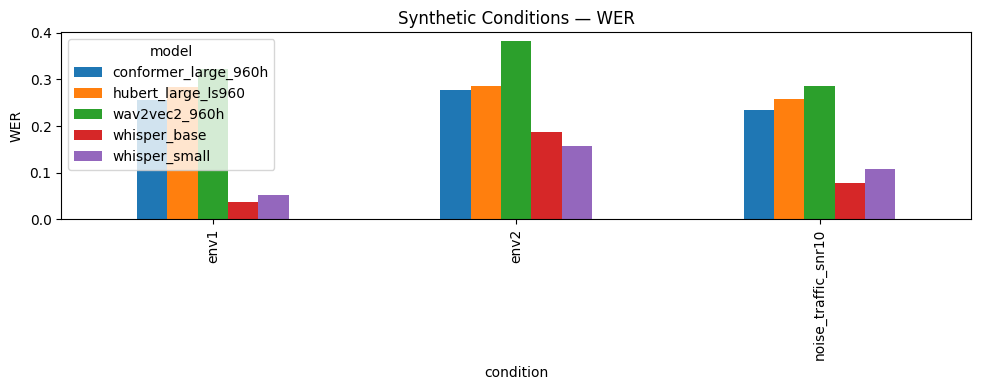

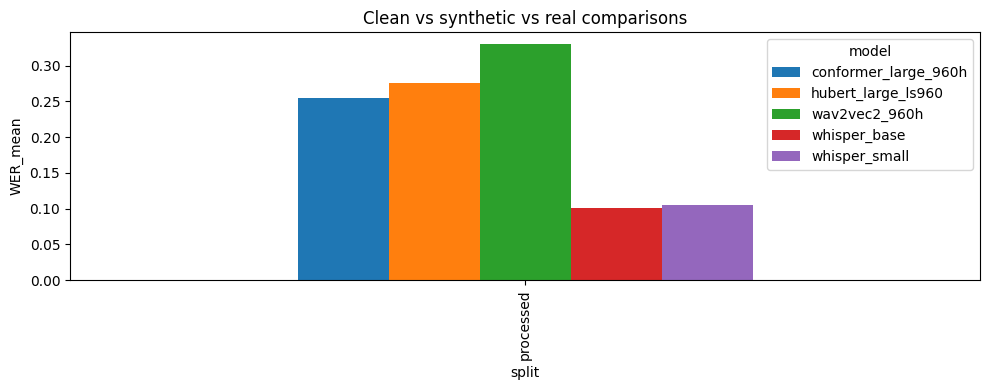

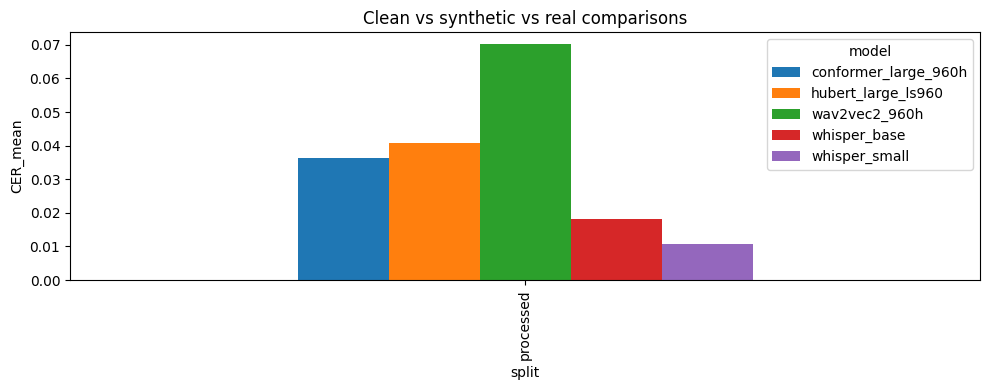

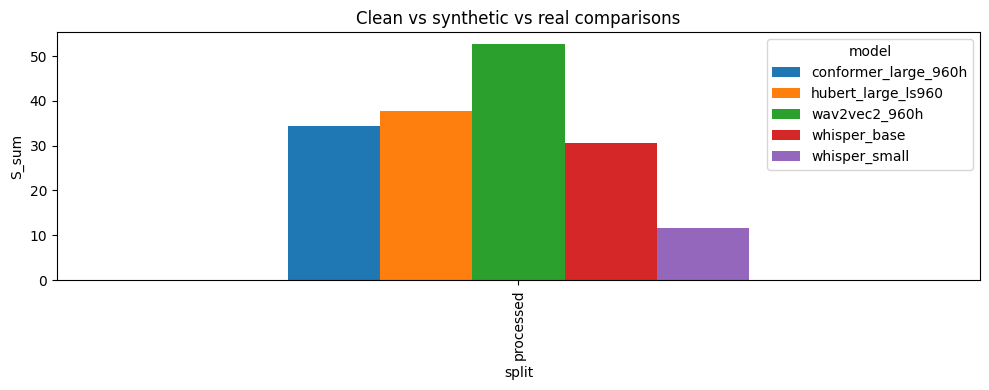

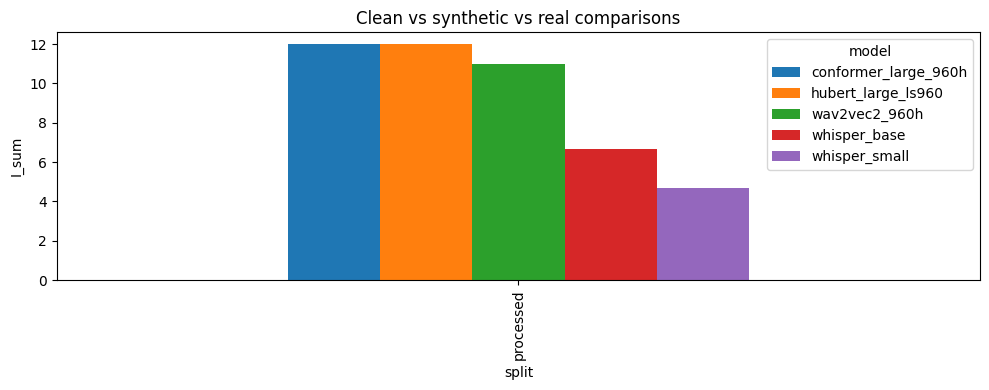

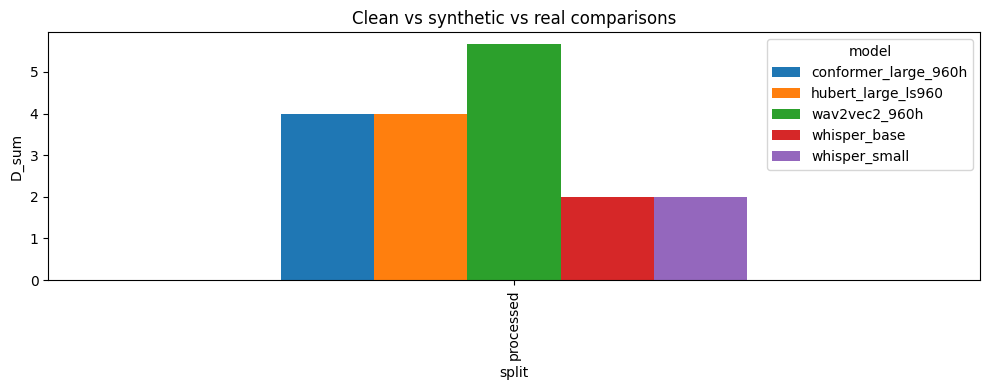

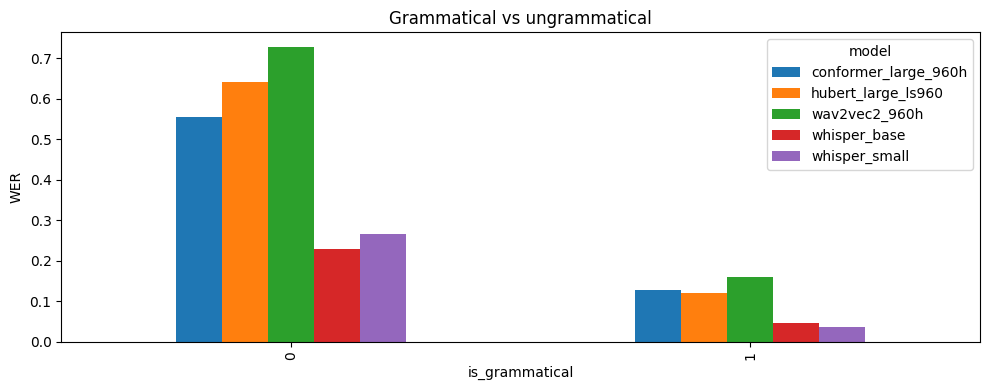

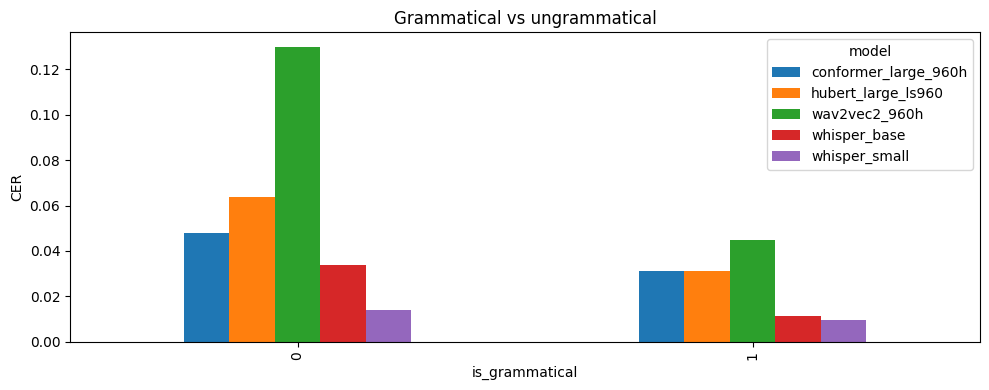

In [ ]:
def summarize(results):
    return (results
            .groupby(["model","split","condition"], as_index=False)
            .agg(WER_mean=("WER","mean"),
                 WER_std=("WER","std"),
                 CER_mean=("CER","mean"),
                 S_sum=("S","sum"),
                 I_sum=("I","sum"),
                 D_sum=("D","sum")))

def plot_wer(summary, title):
    piv = summary.pivot_table(index="condition", columns="model", values="WER_mean")
    ax = piv.plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel("WER")
    plt.tight_layout()
    plt.show()

def compare_split(summary, title, value):
    piv = summary.pivot_table(index="split", columns="model", values=value)
    ax = piv.plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel(value)
    plt.tight_layout()
    plt.show()

def compare_grammar(summary, title, value):
    piv = summary.pivot_table(index="is_grammatical", columns="model", values=value)
    ax = piv.plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel(value)
    plt.tight_layout()
    plt.show()

# Example:
results = pd.read_csv(os.path.join(OUT_DIR, "enhanced_results.csv"))
summary = summarize(results)
summary.to_csv(os.path.join(OUT_DIR, "summary.csv"), index=False)

# 1) WER by condition (per model)
plot_wer(summary[summary.split=="processed"], "Synthetic Conditions — WER")

# 2) Clean vs synthetic vs real comparisons
metrics2 = ["WER_mean","CER_mean", "S_sum", "I_sum", "D_sum"]
for metric in metrics2:
    compare_split(summary,"Clean vs synthetic vs real comparisons",metric)

# 3) Grammatical vs ungrammatical comparisons
metrics3 = ["WER","CER"]
for metric in metrics3:
    compare_grammar(results,"Grammatical vs ungrammatical",metric)

